<a href="https://colab.research.google.com/github/arelkeselbri/pgc305/blob/main/aula0_3_seq2seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PGC305 - Tópicos especiais em LLM e Deep Learning - Prof. Marcelo Keese Albertini

# Preparação dos dados

Esta tarefa é inverter sequências de caracteres. Exemplo: **aabcd** em **dcbaa**.


In [2]:
import torch
import torch.nn as nn
import random

chars = list("abcd ")
vocab = {ch: i for i, ch in enumerate(chars)} # Cada letra, ganha um número
inv_vocab = {i: ch for ch, i in vocab.items()}# Tabela de decodificação
vocab_size = len(vocab)

def encode(s): # Codifica letras em números
    return torch.tensor([vocab[c] for c in s], dtype=torch.long)

def decode(t): # Decodifica números em letras
    return ''.join(inv_vocab[int(x)] for x in t)

def random_seq(n=5): # Cria novas sequências
    return ''.join(random.choice(chars[:-1]) for _ in range(n))

# Gerar dados
pairs = [(encode(s), encode(s[::-1])) for s in [random_seq() for _ in range(50000)]]

max_len = max(len(x) for x, _ in pairs) # pega maior sequência

def pad(x):  # Preenche conjunto de dados em pad no último índice
    return torch.cat([x, torch.tensor([vocab[' ']] * (max_len - len(x)))], dim=0)

inputs = torch.stack([pad(x) for x, _ in pairs])
targets = torch.stack([pad(y) for _, y in pairs])

train_ds = torch.utils.data.TensorDataset(inputs, targets)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Veja um par

In [ ]:
print(pairs[1])

# Definição do modelo Seq2Seq com GRU

In [3]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_size)
        self.gru = nn.GRU(emb_size, hidden_size, batch_first=True)

    def forward(self, x):
        x = self.embed(x)
        _, h = self.gru(x)
        return h  # [1, B, H]

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_size)
        self.gru = nn.GRU(emb_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h):
        """
        x: tensor que indica a parte prévia correta
        h: tensor que indica o estado do encoder da parte prévia
        """
        x = self.embed(x)
        out, h = self.gru(x, h)
        logits = self.fc(out)
        return logits, h # retorna o estado latente para atualizar o estado

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        h = self.encoder(src)
        # usa contexto correto anterior e estado atual para prever o tgt[:, -1]
        logits, _ = self.decoder(tgt[:, :-1], h)
        return logits

# Código para usar o modelo treinado: inferência

In [4]:
def decode_step(decoder, token, h):
    logits, h = decoder(token, h) # obtém logits e atualiza estado da sequência
    next_token = logits[:, -1, :].argmax(-1, keepdim=True)
    return next_token, h

def predict(model, seq, max_len=10):
    model.eval()
    with torch.no_grad():
        src = pad(encode(seq)).unsqueeze(0).to(device, dtype=torch.long)
        h = model.encoder(src) # Obtém estado do modelo após processar entrada inicial

        # 'token' representa a geração passo a passo da sequência invertida
        token = torch.tensor([[vocab[' ']]], dtype=torch.long, device=device)
        seq_invertida = []
        for _ in range(max_len):
            token, h = decode_step(model.decoder, token, h)
            seq_invertida.append(token.item())
        return decode(seq_invertida)

# Preparação para treino

In [5]:
emb_size = 32
hidden_size = 64
encoder = Encoder(vocab_size, emb_size, hidden_size)
decoder = Decoder(vocab_size, emb_size, hidden_size)
model = Seq2Seq(encoder, decoder).to(device)

loss_fn = nn.CrossEntropyLoss(ignore_index=vocab[' ']) # ignora o pad: " "
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# Execução do treino

In [6]:
for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device, dtype=torch.long), yb.to(device, dtype=torch.long)
        opt.zero_grad()
        logits = model(xb, yb)
        loss = loss_fn(logits.reshape(-1, vocab_size), yb[:, 1:].reshape(-1))
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: loss={total_loss/len(train_dl):.4f}")

Epoch 1: loss=0.3269
Epoch 2: loss=0.0054
Epoch 3: loss=0.0017
Epoch 4: loss=0.0009
Epoch 5: loss=0.0005
Epoch 6: loss=0.0003
Epoch 7: loss=0.0002
Epoch 8: loss=0.0002
Epoch 9: loss=0.0001
Epoch 10: loss=0.0001


# Vamos testar

In [7]:
for _ in range(10):
    s = random_seq()
    pred = predict(model, s, max_len=len(s))
    print(f"{s} -> {pred}")


aaccd -> cddac
cbccd -> cdbcd
aadba -> abdac
aabcb -> bcacb
ddcaa -> aacdc
ddabd -> dbabd
cadab -> baadc
cbbca -> acbcd
acdbc -> cbdca
badca -> accda


# Exercício
Compare o resultado do uso do encoder de de sequências muito similares e muito diferentes. Por exemplo, codifique "aaaabb", "bbaaab", "cbcaccc" e "cccacbc" e depois faça uma figura das 2 componentes principais usando o método Principal Components Analysis (PCA) do pacote `sklearn.decomposition.PCA`.

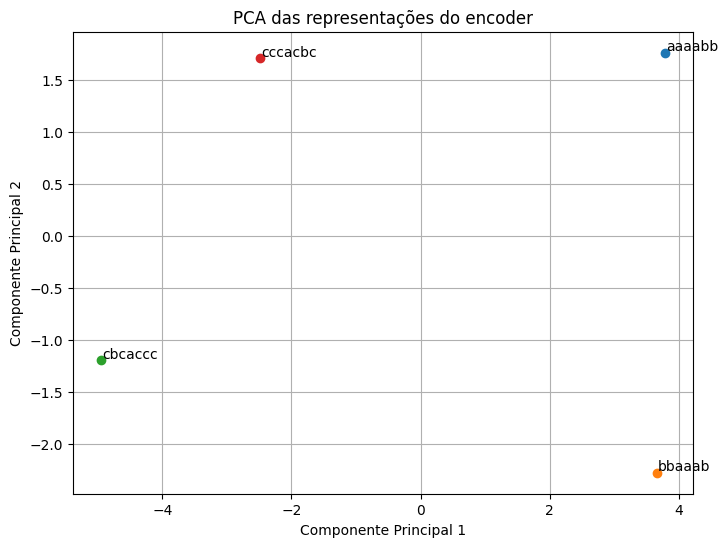

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch

seqs = ["aaaabb", "bbaaab", "cbcaccc", "cccacbc"]

# modo de testes para obter as representações do encoder
model.eval()
representacoes = []

# Obter as representações do encoder para cada sequência sem gradientes 
with torch.no_grad():
    for s in seqs:
        x = pad(encode(s)).unsqueeze(0).to(device, dtype=torch.long)  # [1, T]
        h = model.encoder(x)  # [1, 1, H]
        vetor = h.squeeze(0).squeeze(0).cpu().numpy()  # [H]
        representacoes.append(vetor)

# PCA para reduzir para 2 dimensões (64 dimensoes para 2 - hidden_size para 2)
pca = PCA(n_components=2)
coords = pca.fit_transform(representacoes)

# Gráfico
plt.figure(figsize=(8, 6))
for i, s in enumerate(seqs):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, s, fontsize=10)

plt.title("PCA das representações do encoder")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()